In [5]:
import params, os, funcs
from jaratoolbox import celldatabase, settings
import numpy as np

# Load dataframe
databaseDir = os.path.join(settings.DATABASE_PATH, '2024popanalysis')
fullDbPath = 'celldb_2024popanalysis.h5'
fullPath = os.path.join(databaseDir, fullDbPath)
fullDb = celldatabase.load_hdf(fullPath)
simpleSiteNames = fullDb["recordingSiteName"].str.split(',').apply(lambda x: x[0])
simpleSiteNames = simpleSiteNames.replace("Posterior auditory area", "Dorsal auditory area")
fullDb["recordingSiteName"] = simpleSiteNames
fullDb.head()

,behavSuffix,bestChannel,brainArea,cluster,cluster_label,date,egroup,ephysTime,info,maxDepth,...,pdepth,probe,recordingSiteName,recordingTrack,sessionType,spikeShape,subject,x_coord,y_coord,z_coord
0,"[a, b, a, b]",1,AC_right,1,good,2022-01-11,0,"[13-48-00, 13-55-58, 14-06-21, 14-20-08]","[facesMedial, soundLeft]",2318,...,2318,NPv1-2872,Primary auditory area,anteromedialDiD,"[AM, pureTones, VOT, FT]","[0.025128685, 0.020350156, 0.022057759, 0.0216...",feat004,397.032812,121.802719,201.0
1,"[a, b, a, b]",2,AC_right,7,good,2022-01-11,0,"[13-48-00, 13-55-58, 14-06-21, 14-20-08]","[facesMedial, soundLeft]",2318,...,2318,NPv1-2872,Primary auditory area,anteromedialDiD,"[AM, pureTones, VOT, FT]","[-0.0016647133, 0.01399436, 0.014463621, 0.017...",feat004,396.952150,121.215818,201.0
2,"[a, b, a, b]",5,AC_right,11,good,2022-01-11,0,"[13-48-00, 13-55-58, 14-06-21, 14-20-08]","[facesMedial, soundLeft]",2318,...,2318,NPv1-2872,Primary auditory area,anteromedialDiD,"[AM, pureTones, VOT, FT]","[0.011408528, 0.006604709, 0.0063931295, 0.003...",feat004,396.871488,120.628918,201.0
3,"[a, b, a, b]",5,AC_right,13,good,2022-01-11,0,"[13-48-00, 13-55-58, 14-06-21, 14-20-08]","[facesMedial, soundLeft]",2318,...,2318,NPv1-2872,Primary auditory area,anteromedialDiD,"[AM, pureTones, VOT, FT]","[0.008579502, 0.0046604094, 0.0045404034, 0.00...",feat004,396.871488,120.628918,201.0
4,"[a, b, a, b]",5,AC_right,14,good,2022-01-11,0,"[13-48-00, 13-55-58, 14-06-21, 14-20-08]","[facesMedial, soundLeft]",2318,...,2318,NPv1-2872,Primary auditory area,anteromedialDiD,"[AM, pureTones, VOT, FT]","[0.000733526, 0.028997183, 0.024717774, 0.0263...",feat004,396.871488,120.628918,201.0


In [6]:
X_speech_all, Y_brain_area_speech_all, X_AM_all = {}, {}, {}
Y_brain_area_AM_all, X_pureTones_all, Y_brain_area_PT_all = {}, {}, {}
previous_frequency_speech, previous_frequency_AM, previous_frequency_PT = None, None, None
indices_AM, indices_PT, indices_speech = None, None, None

# Initialize dictionaries for each spike window
for window_name in params.spike_windows:
    if "speech" in window_name:
        X_speech_all[window_name] = []
        Y_brain_area_speech_all[window_name] = []
    if "am" in window_name:
        X_AM_all[window_name] = []
        Y_brain_area_AM_all[window_name] = []
    if "pt" in window_name:
        X_pureTones_all[window_name] = []
        Y_brain_area_PT_all[window_name] = []

In [7]:
def spike_rate(sound_type, ensemble, ephysData, bdata, targetSiteName, spike_windows):
    '''
    Calculate firing rates for multiple evoked spike windows.

    Returns a dictionary of spikeRateNormalized arrays keyed by window name.
    Each value is (trials, neurons).
    
    sound_type = ['speech', 'pt', 'am']
    '''
    X_dict = {}
    Y_brain_area_array = []
    Y_frequency = None

    if sound_type == "speech":
        eventOnsetTimes = ephysData['events']['stimOn']
        FTParamsEachTrial = bdata['targetFTpercent']
        VOTParamsEachTrial = bdata['targetVOTpercent']
        Y_frequency = np.array([(FTParamsEachTrial[i], VOTParamsEachTrial[i]) for i in range(len(FTParamsEachTrial))])

    else:  # AM or PT
        eventOnsetTimes = ephysData['events']['stimOn'][:len(bdata['currentFreq'])]
        Y_frequency = np.array(bdata['currentFreq'])

    # Loop over relevant windows for this sound_type
    for label, (start, end) in params.spike_windows.items():
        if sound_type in label:
            _, _, _ = ensemble.eventlocked_spiketimes(eventOnsetTimes, [start, end])
            spikeCounts = ensemble.spiketimes_to_spikecounts(np.arange(start, end, 0.01))  # Bin width of 10 ms
            sumEvokedFR = spikeCounts.sum(axis=2)
            spikesPerSecEvoked = sumEvokedFR / (end - start)

            trialMeans = spikesPerSecEvoked.mean(axis=1)
            spikesPerSecEvokedNormalized = spikesPerSecEvoked.T - trialMeans
            spikesPerSecEvokedNormalized = spikesPerSecEvokedNormalized.T

            if spikesPerSecEvokedNormalized.shape[1] > params.leastCellsArea:
                subsetIndex = np.random.choice(spikesPerSecEvokedNormalized.shape[1], params.leastCellsArea, replace=False)
                spikeRateNormalized = spikesPerSecEvokedNormalized[:, subsetIndex]
            else:
                spikeRateNormalized = spikesPerSecEvokedNormalized

            X_dict[label] = spikeRateNormalized
            Y_brain_area_array = [targetSiteName] * spikeRateNormalized.shape[0]

    return X_dict, Y_brain_area_array, Y_frequency

In [8]:
# Add data to the dictionary for each brain area and sound type
for subject in params.subject_list:
    for date in params.recordingDate_list[subject]:
        for brain_area in params.targetSiteNames:
            speechEnsemble, speechEphys, speechBdata = funcs.load_data(subject, date, brain_area, "FTVOTBorders")

            if speechEnsemble:
                X_speech_dict, Y_brain_area_speech, Y_frequency_speech = spike_rate("speech", speechEnsemble, speechEphys, speechBdata, brain_area, params.spike_windows)
                for window_name, X_speech in X_speech_dict.items():
                    X_speech_array, Y_frequency_speech_sorted, previous_frequency_speech, indices_speech = (
                        funcs.adjust_speech_length(subject, date, brain_area, X_speech, Y_frequency_speech,
                                                   Y_brain_area_speech, previous_frequency_speech))
                    
                    if X_speech_array is not None:
                        Y_frequency_FT = Y_frequency_speech_sorted[:, 0]
                        Y_frequency_VOT = Y_frequency_speech_sorted[:, 1]
                
                        X_speech_all[window_name].extend(X_speech_array)
                        Y_brain_area_speech_all[window_name].extend(Y_brain_area_speech)

            # Load and process data for AM
            amEnsemble, amEphys, amBdata = funcs.load_data(subject, date, brain_area, "AM")
            if amEnsemble:
                X_AM_dict, Y_brain_area_AM, Y_frequency_AM = spike_rate("am", amEnsemble, amEphys, amBdata, 
                                                                        brain_area, params.spike_windows)
                
                for window_name, X_AM in X_AM_dict.items():
                    # Apply adjustments
                    X_AM_adjusted, Y_frequency_AM_adjusted, Yba_AM_adj = (
                        funcs.adjust_array_and_labels(X_AM, Y_frequency_AM, Y_brain_area_AM, 
                                                      params.max_trials['AM'], subject, date, brain_area))
                
                    # Sort arrays
                    X_AM_array, Y_frequency_AM_sorted, Y_brain_area_AM_sorted, previous_frequency_AM, indices_AM = (
                        funcs.sort_sound_array(subject, date, brain_area, X_AM_adjusted, Yba_AM_adj, Y_frequency_AM_adjusted, previous_frequency_AM))
                
                    X_AM_all[window_name].extend(X_AM_array)
                    Y_brain_area_AM_all[window_name].extend(Y_brain_area_AM_sorted)
                        
            # Load and process data for PT
            ptEnsemble, ptEphys, ptBdata = funcs.load_data(subject, date, brain_area, "pureTones")
            if ptEnsemble:
                X_PT_dict, Y_brain_area_PT, Y_frequency_pureTones = spike_rate("pt", ptEnsemble, ptEphys, ptBdata, 
                                                                        brain_area, params.spike_windows)
                for window_name, X_PT in X_PT_dict.items():
                    # Apply adjustments
                    X_PT_adjusted, Y_frequency_PT_adjusted, Yba_PT_adj = (
                        funcs.adjust_array_and_labels(X_PT, Y_frequency_pureTones, Y_brain_area_PT, 
                                                      params.max_trials['PT'], subject, date, brain_area))
                
                    # Sort arrays
                    X_PT_array, Y_frequency_PT_sorted, Y_brain_area_PT_sorted, previous_frequency_PT, indices_PT = (
                        funcs.sort_sound_array(subject, date, brain_area, X_PT_adjusted, Yba_PT_adj, 
                                               Y_frequency_PT_adjusted, previous_frequency_PT))
                
                    if X_PT_array is not None:
                        X_pureTones_all[window_name].extend(X_PT_array)
                        Y_brain_area_PT_all[window_name].extend(Y_brain_area_PT_sorted)

No FTVOTBorder data for Primary auditory area on 2022-01-11 for feat004
Not enough PT trials recorded for subject feat004, on 2022-01-11 in brain area Primary auditory area.
Not enough PT trials recorded for subject feat004, on 2022-01-11 in brain area Primary auditory area.
Not enough PT trials recorded for subject feat004, on 2022-01-11 in brain area Primary auditory area.
No FTVOTBorder data for Dorsal auditory area on 2022-01-11 for feat004
Not enough PT trials recorded for subject feat004, on 2022-01-11 in brain area Dorsal auditory area.
Not enough PT trials recorded for subject feat004, on 2022-01-11 in brain area Dorsal auditory area.
Not enough PT trials recorded for subject feat004, on 2022-01-11 in brain area Dorsal auditory area.
No data in Ventral auditory area on 2022-01-11 for Speech, AM, and PT.
No data in Ventral auditory area on 2022-01-11 for Speech, AM, and PT.
No data in Ventral auditory area on 2022-01-11 for Speech, AM, and PT.
No FTVOTBorder data for Primary aud

In [39]:
# Mapping from old window names to simplified names
window_name_mapping = {
    'am - speech - onset': 'onset',
    'am - speech - sustained': 'sustained',
    'am - speech - offset': 'offset',
    'pt - onset': 'onset',
    'pt - sustained': 'sustained',
    'pt - offset': 'offset',
}

# --- AM ---
X_AM_dict = {}
Y_brain_area_AM_all_renamed = {}

for window_name, X_AM_list in X_AM_all.items():
    simple_name = window_name_mapping.get(window_name, window_name)
    X_AM_sorted = funcs.sort_x_arrays(X_AM_list, indices_AM, "am")
    X_AM_array = np.stack(X_AM_sorted, axis=0)
    X_AM_dict[simple_name] = X_AM_array

    if window_name in Y_brain_area_AM_all:
        Y_brain_area_AM_all_renamed[simple_name] = Y_brain_area_AM_all[window_name]

# --- PT ---
X_PT_dict = {}
Y_brain_area_PT_all_renamed = {}

for window_name, X_PT_list in X_pureTones_all.items():
    simple_name = window_name_mapping.get(window_name, window_name)
    X_PT_sorted = funcs.sort_x_arrays(X_PT_list, indices_PT, "pt")
    X_PT_array = np.stack(X_PT_sorted, axis=0)
    X_PT_dict[simple_name] = X_PT_array

    if window_name in Y_brain_area_PT_all:
        Y_brain_area_PT_all_renamed[simple_name] = Y_brain_area_PT_all[window_name]

# --- Speech ---
X_speech_dict = {}
Y_brain_area_speech_all_renamed = {}

for window_name, X_speech_list in X_speech_all.items():
    simple_name = window_name_mapping.get(window_name, window_name)
    X_speech_sorted = funcs.sort_x_arrays(X_speech_list, indices_speech, "speech")
    X_speech_array = np.stack(X_speech_sorted, axis=0)
    X_speech_dict[simple_name] = X_speech_array

    if window_name in Y_brain_area_speech_all:
        Y_brain_area_speech_all_renamed[simple_name] = Y_brain_area_speech_all[window_name]

In [40]:
print(f"AM Onset Shape: {X_AM_dict['onset'].shape}")
print(f"AM Sustained Shape: {X_AM_dict['sustained'].shape}")
print(f"AM Offset Shape: {X_AM_dict['offset'].shape}")

print(f"PT Onset Shape: {X_PT_dict['onset'].shape}")
print(f"PT Sustained Shape: {X_PT_dict['sustained'].shape}")
print(f"PT Offset Shape: {X_PT_dict['offset'].shape}")

print(f"Speech Onset Shape: {X_speech_dict['onset'].shape}")
print(f"Speech Sustained Shape: {X_speech_dict['sustained'].shape}")
print(f"Speech Offset Shape: {X_speech_dict['offset'].shape}")

AM Onset Shape: (557, 220)
AM Sustained Shape: (557, 220)
AM Offset Shape: (557, 220)
PT Onset Shape: (431, 640)
PT Sustained Shape: (431, 640)
PT Offset Shape: (431, 640)
Speech Onset Shape: (400, 381)
Speech Sustained Shape: (400, 381)
Speech Offset Shape: (400, 381)


In [43]:
data_dict = {}

for brain_area in params.targetSiteNames:
    for window_name in X_speech_dict:
        brain_area_mask = np.array(Y_brain_area_speech_all_renamed[window_name]) == brain_area
        X_array = X_speech_dict[window_name][brain_area_mask].T
        data_dict[(brain_area, 'speech', window_name)] = {'X': X_array, 'Y': Y_frequency_speech_sorted}

    for window_name in X_AM_dict:
        brain_area_mask = np.array(Y_brain_area_AM_all_renamed[window_name]) == brain_area
        X_array = X_AM_dict[window_name][brain_area_mask].T
        data_dict[(brain_area, 'AM', window_name)] = {'X': X_array, 'Y': Y_frequency_AM_sorted}

    for window_name in X_PT_dict:
        brain_area_mask = np.array(Y_brain_area_PT_all_renamed[window_name]) == brain_area
        X_array = X_PT_dict[window_name][brain_area_mask].T
        data_dict[(brain_area, 'PT', window_name)] = {'X': X_array, 'Y': Y_frequency_PT_sorted}
        
data_dict[('Ventral auditory area', 'AM', 'onset')]['X'].shape

(220, 119)

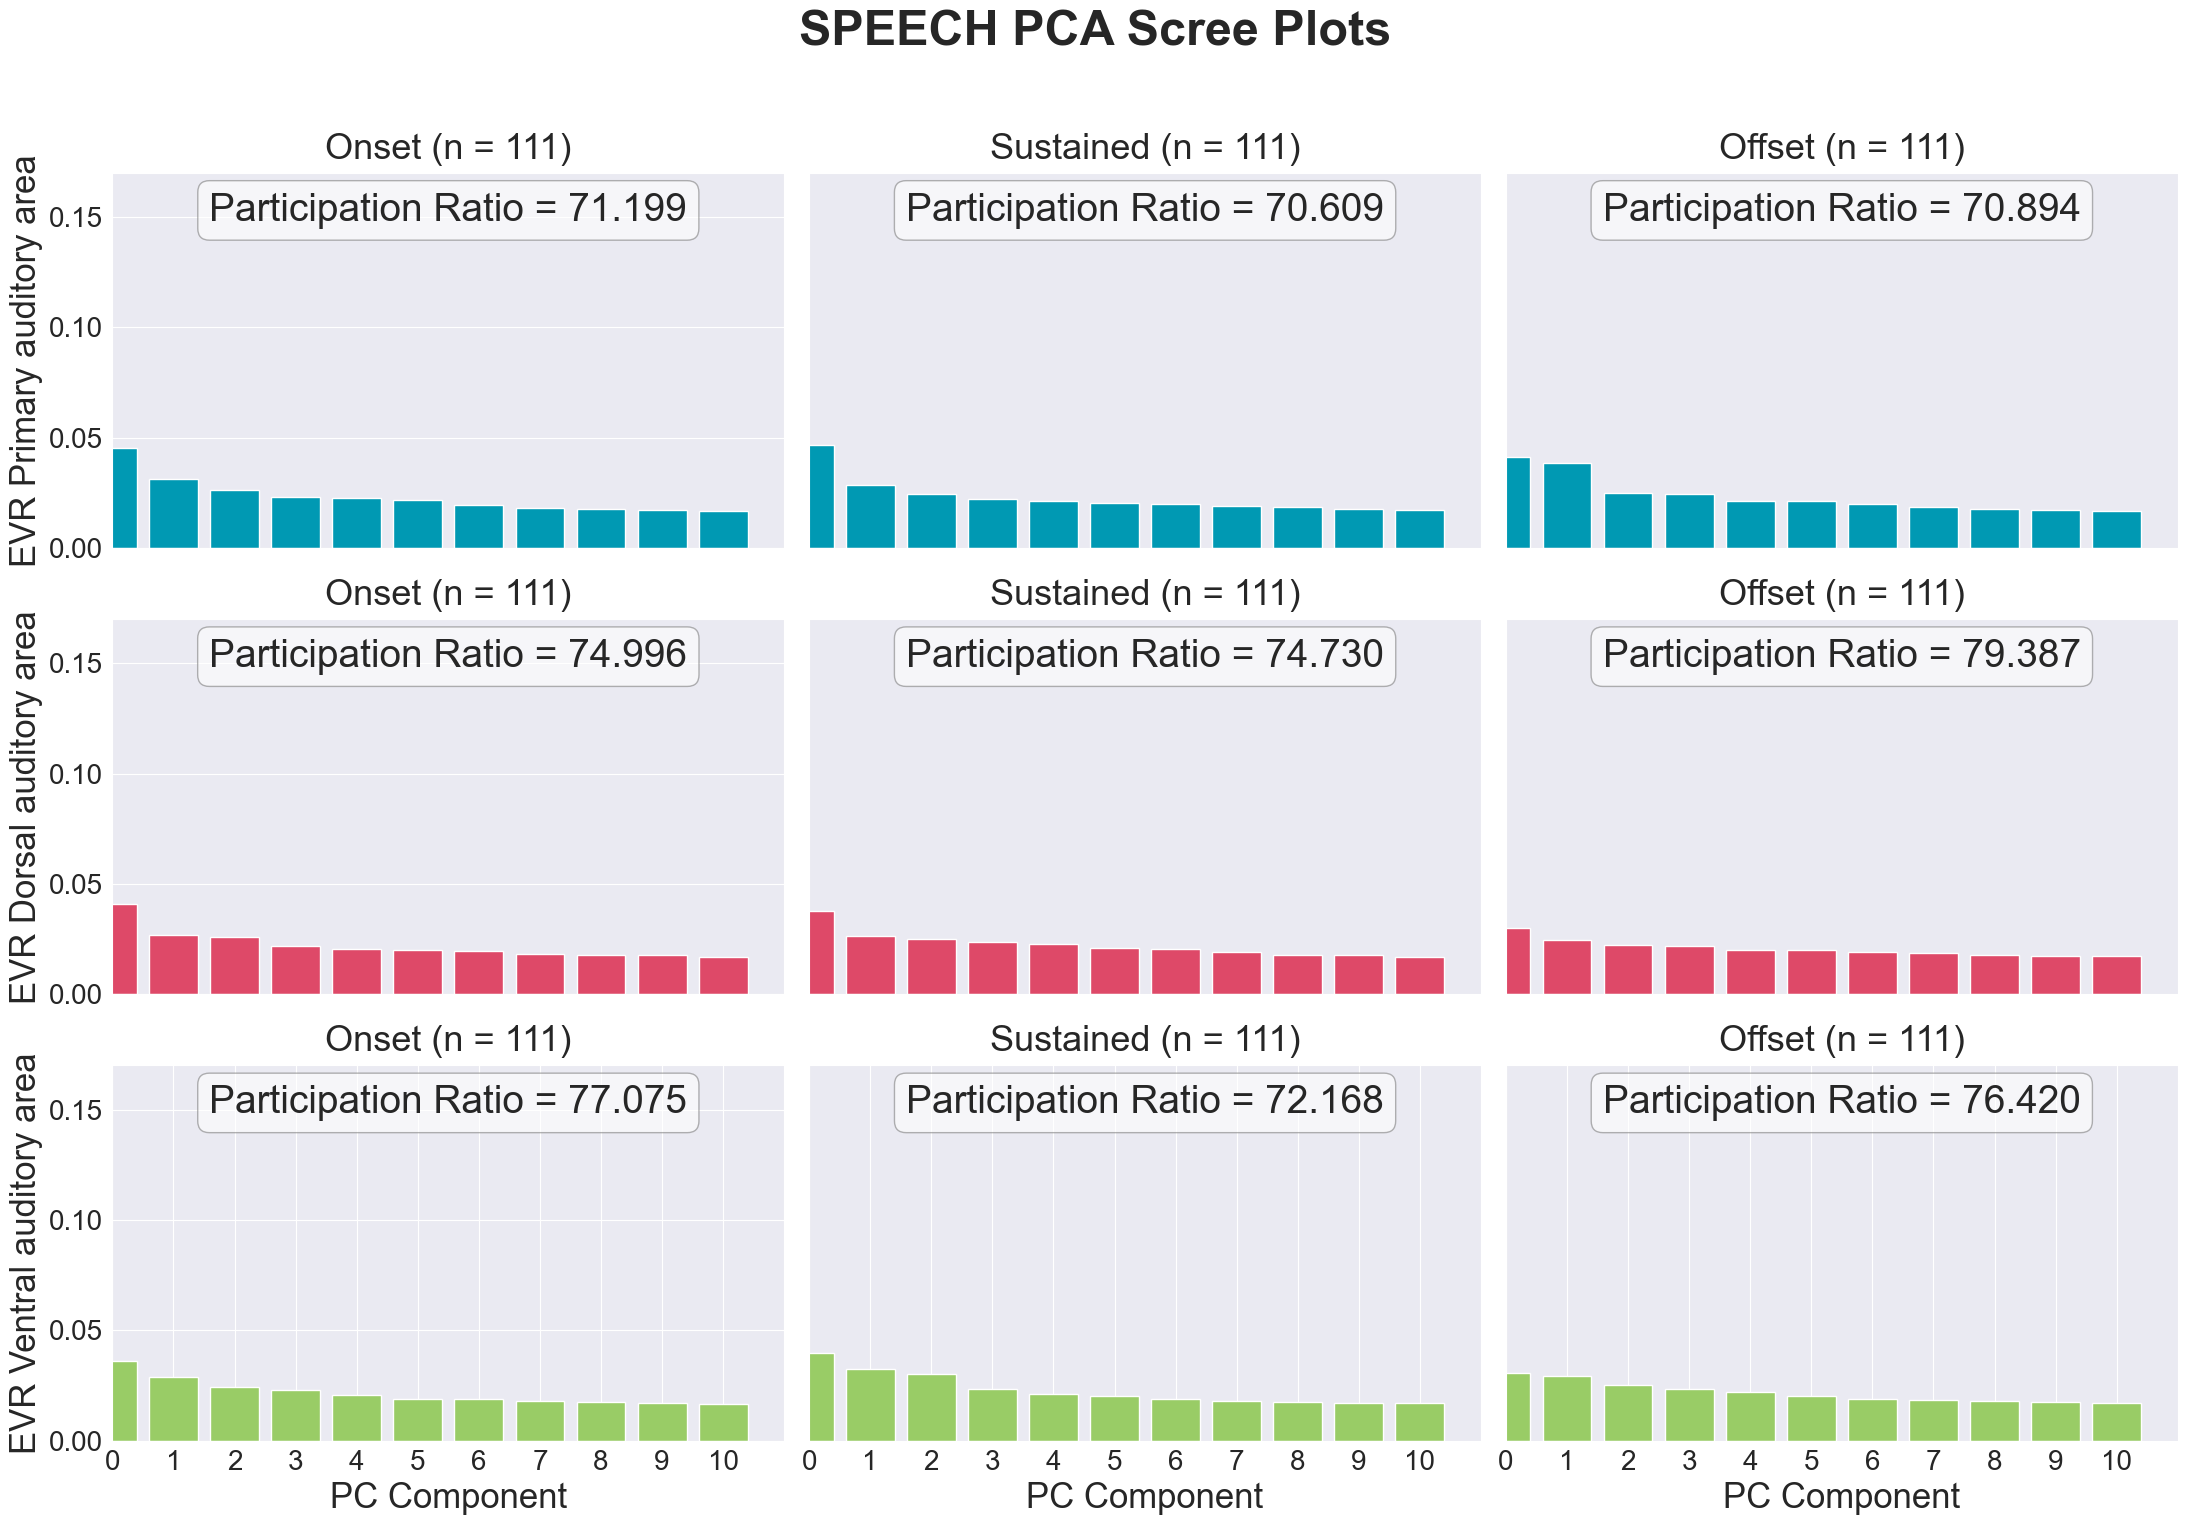

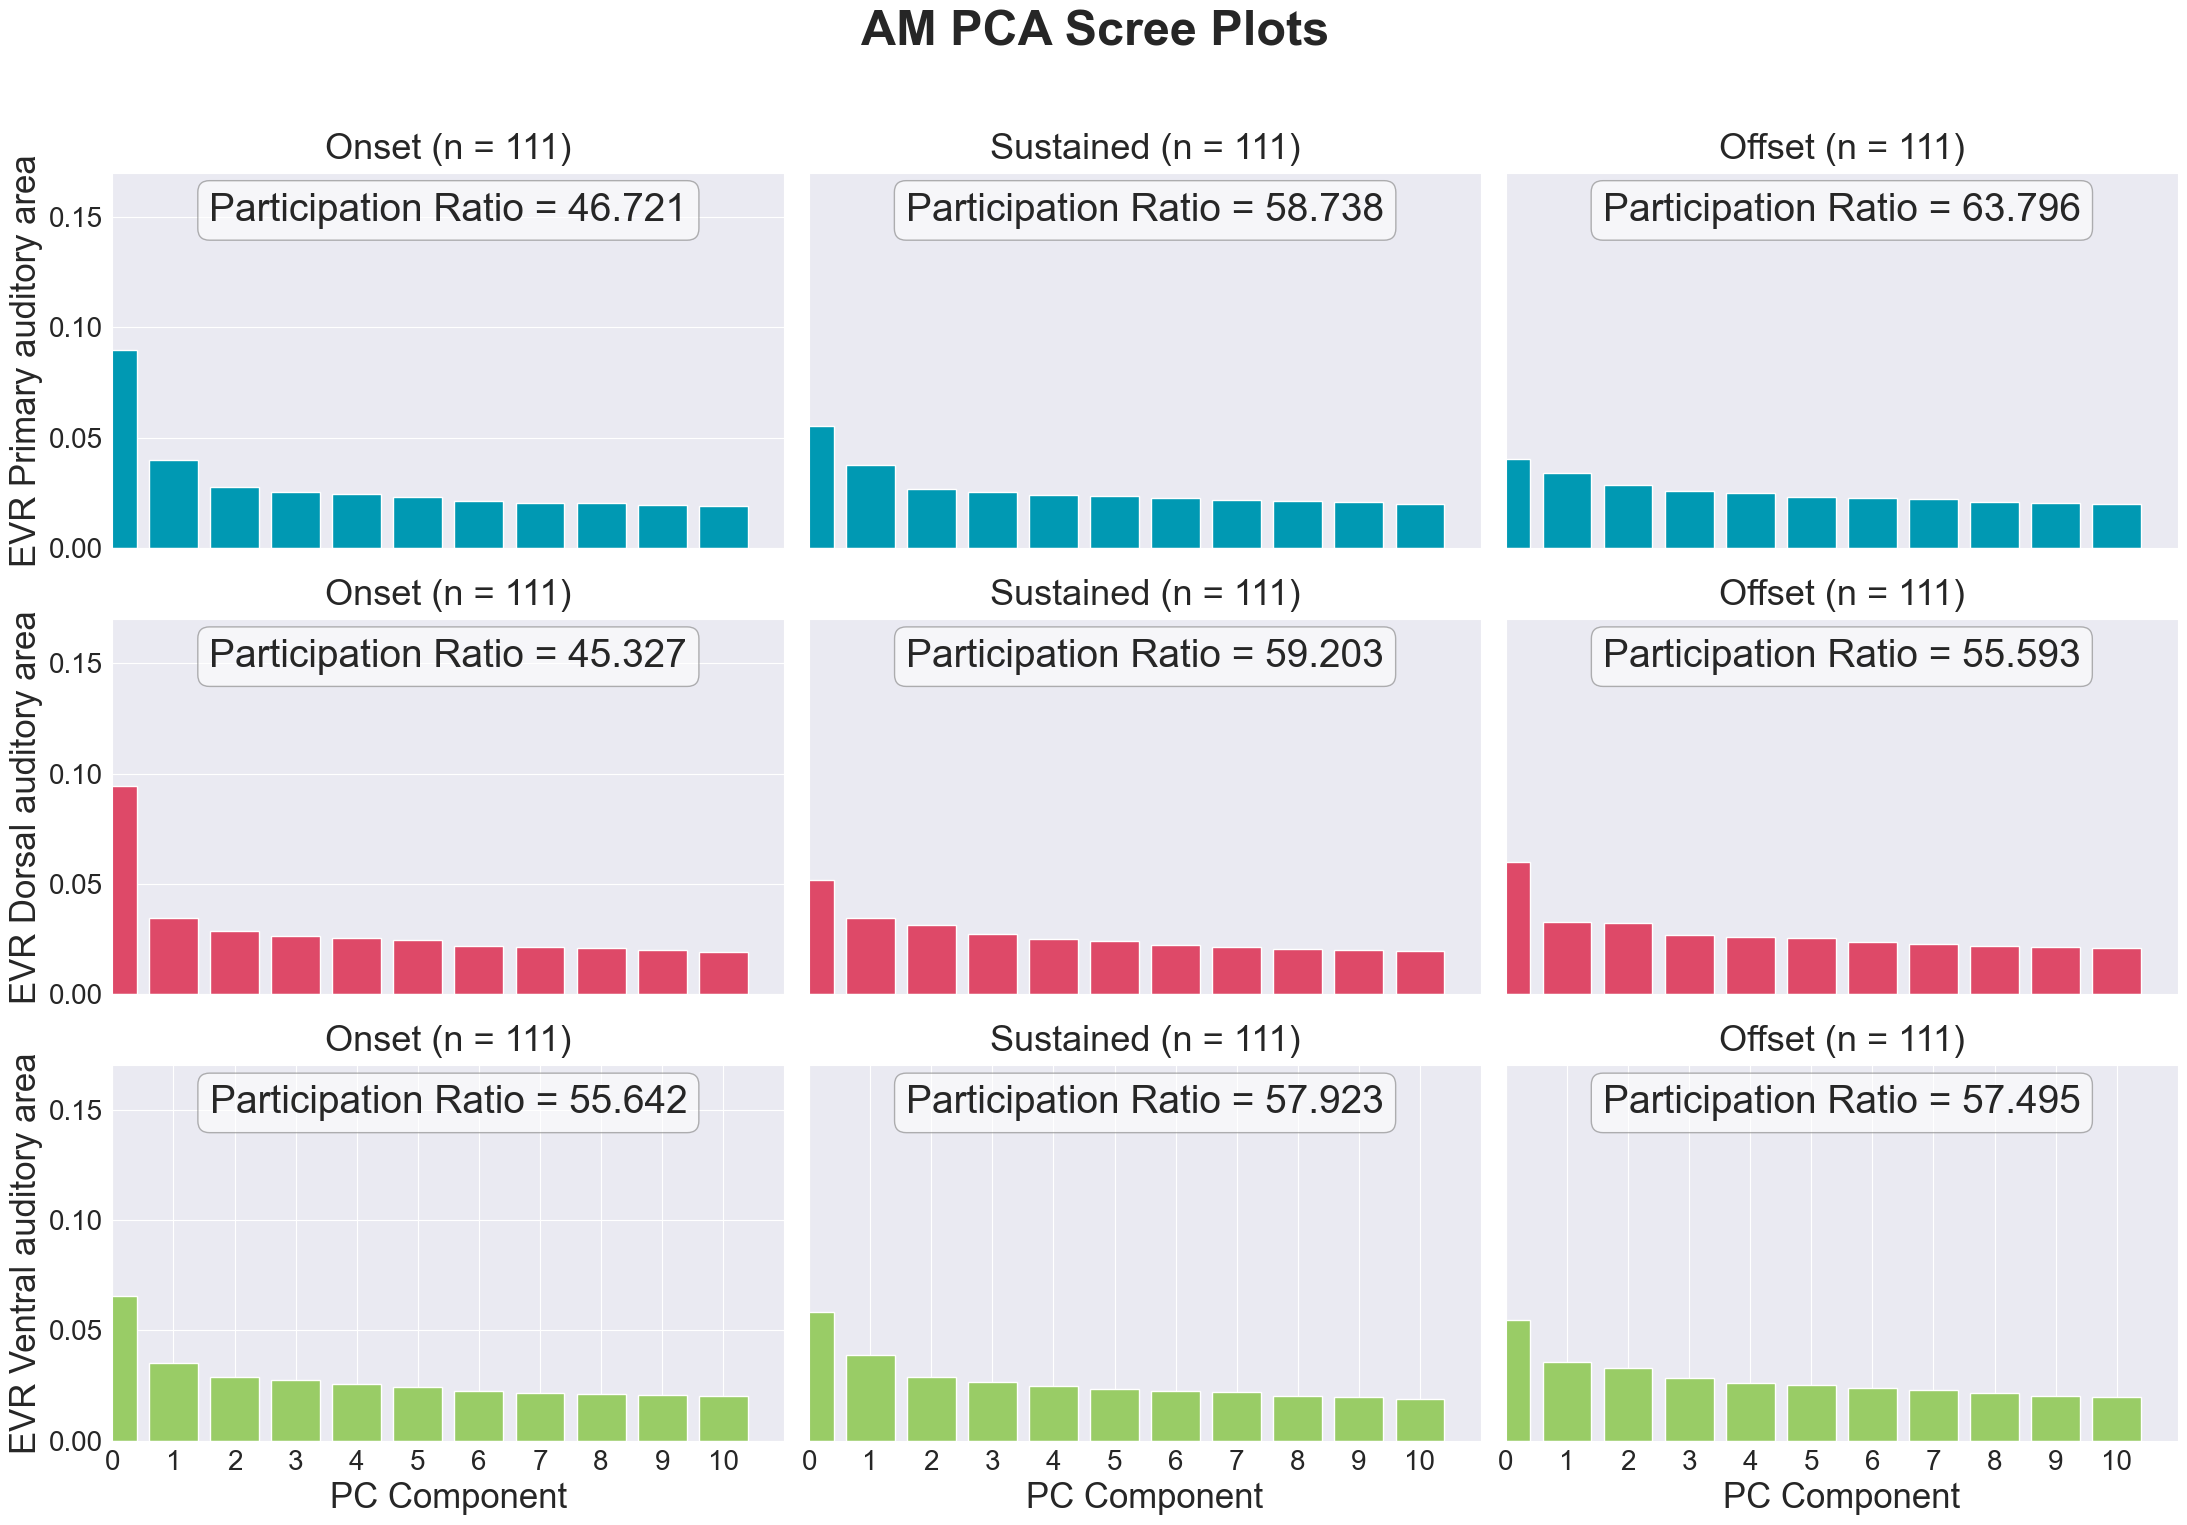

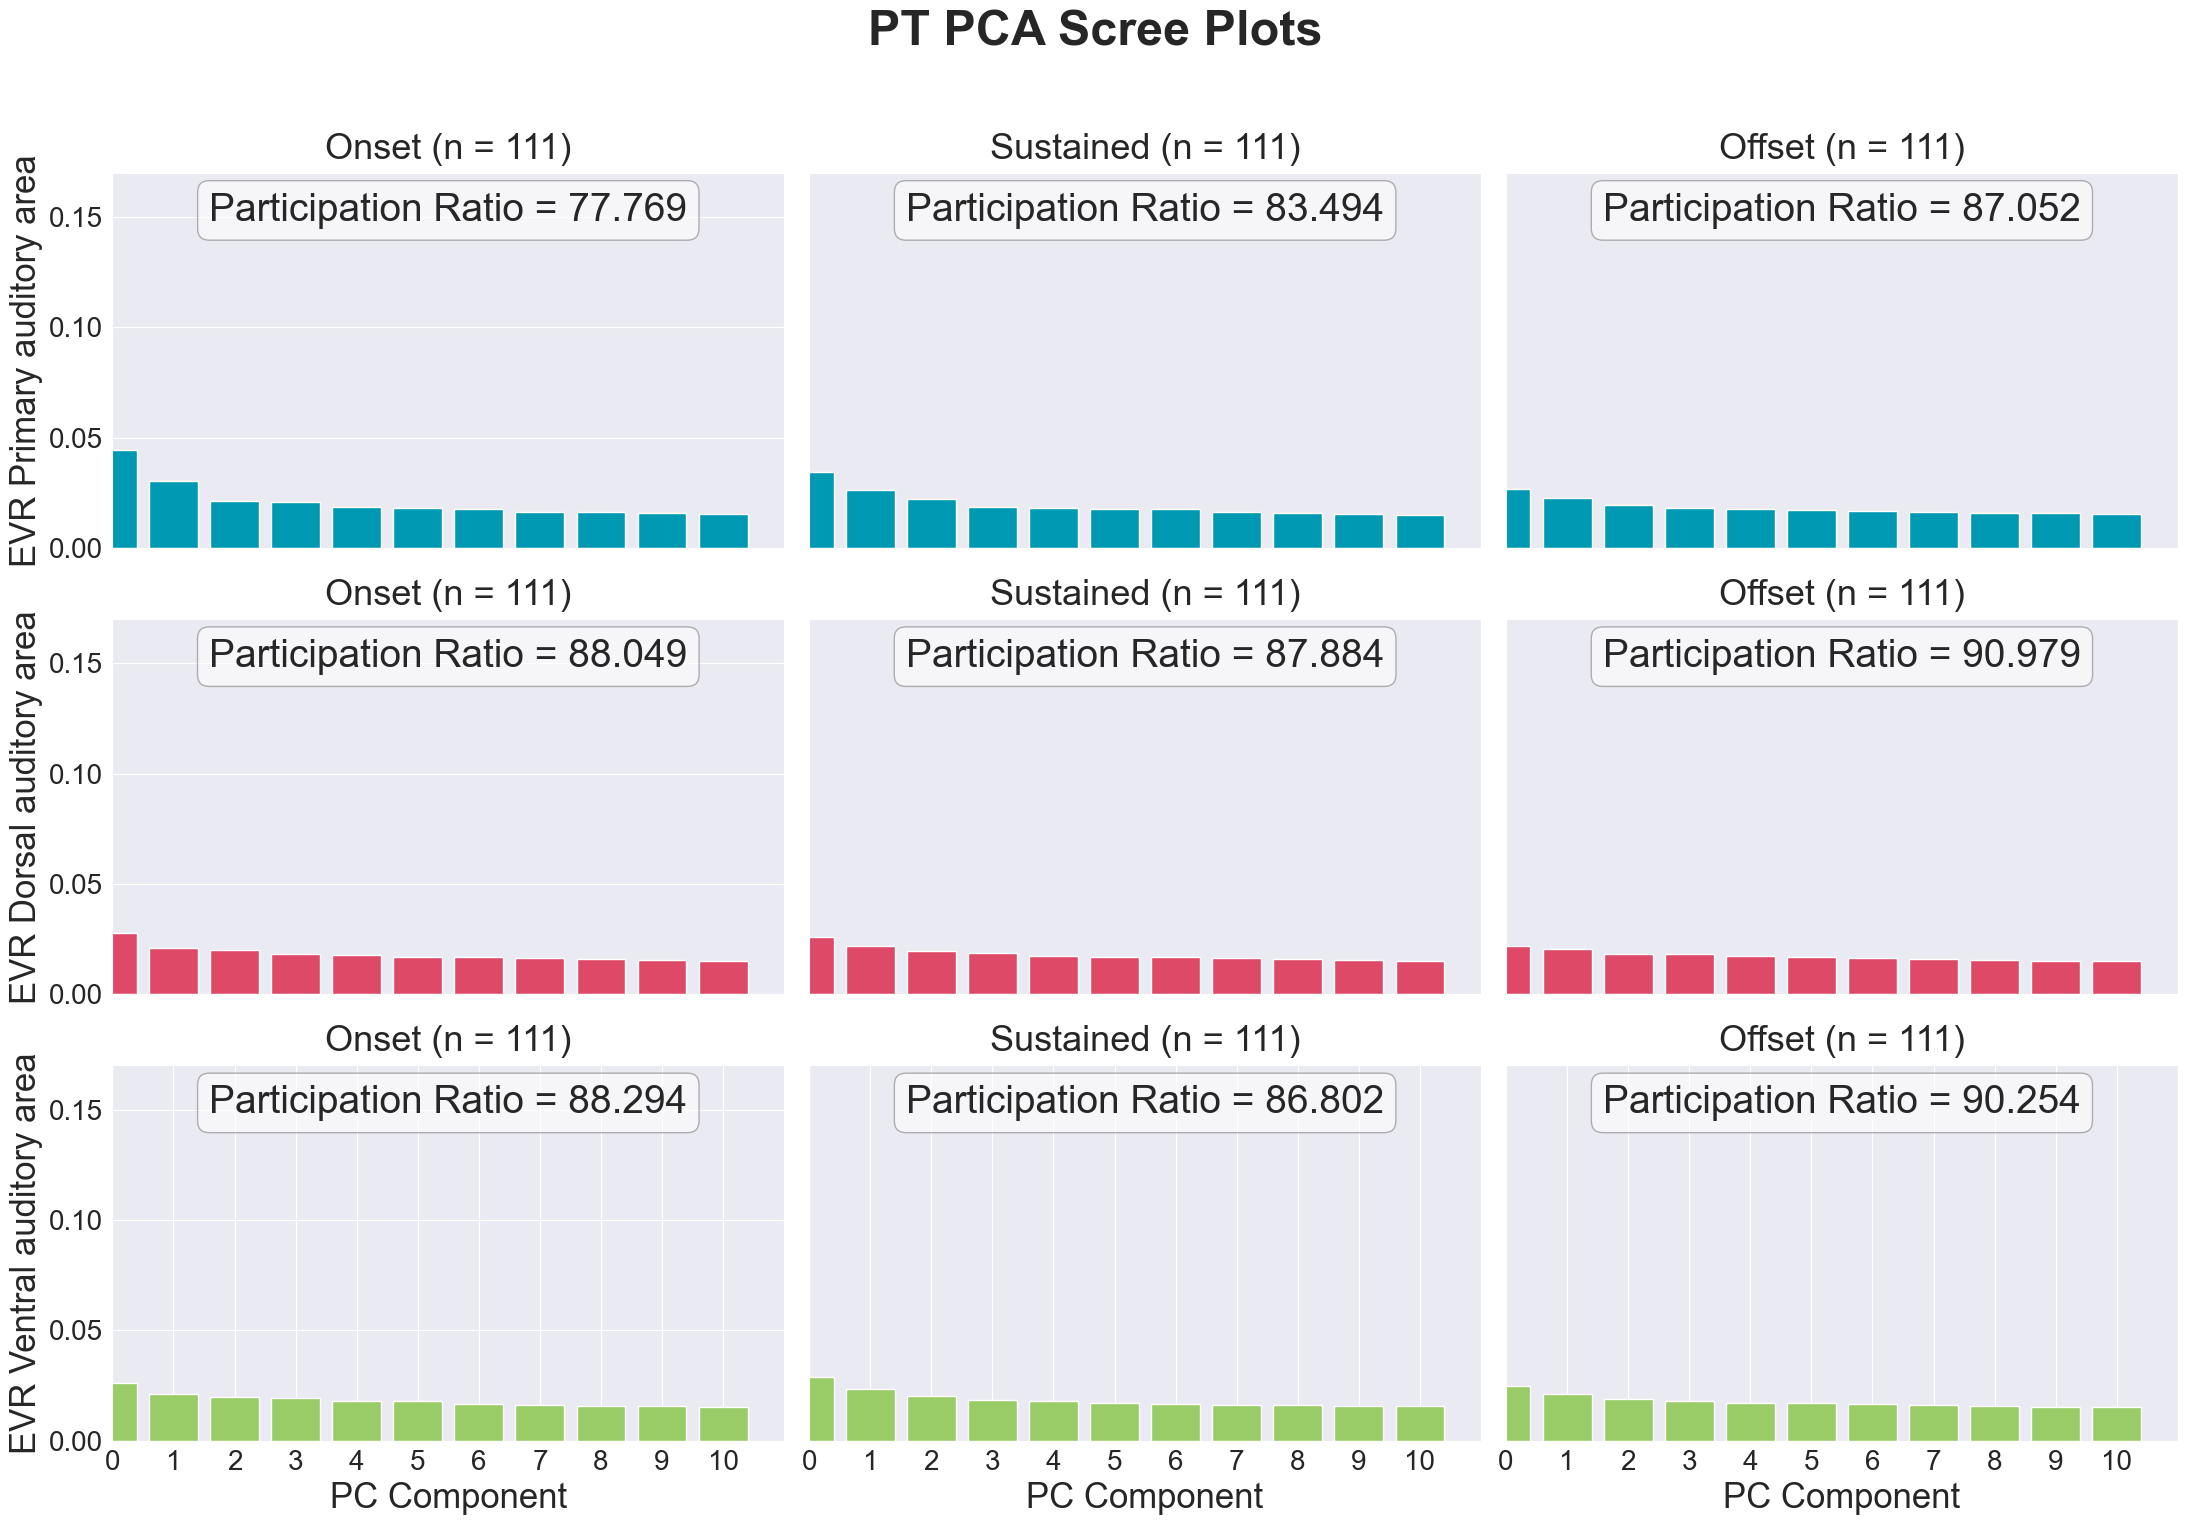

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib import cm

# Define spike windows in correct order
spike_windows = ['onset', 'sustained', 'offset']
area_cmaps = {
    "Primary auditory area": cm.winter,
    "Dorsal auditory area": cm.magma,
    "Ventral auditory area": cm.summer,
}
y_max = 0.17

for sound_type in ['speech', 'AM', 'PT']:
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle(f'{sound_type.upper()} PCA Scree Plots', fontweight='bold', fontsize=35)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, brain_area in enumerate(params.targetSiteNames):
        for j, window_name in enumerate(spike_windows):
            ax = axes[i, j]
            key = (brain_area, sound_type, window_name)
            if key not in data_dict:
                ax.axis('off')
                continue

            data = data_dict[key]
            cmap = area_cmaps.get(brain_area, cm.viridis)
            X = data['X']
            n_neurons = X.shape[1]
            if n_neurons < 2:
                ax.axis('off')
                continue

            selected = np.random.choice(n_neurons, min(111, n_neurons), replace=False)
            X_sub = StandardScaler().fit_transform(X[:, selected])

            pca = PCA()
            pca.fit(X_sub)
            explained = pca.explained_variance_ratio_
            pr = funcs.calculate_participation_ratio(explained)

            funcs.plot_scree_plot(ax, X_sub, title=None, y_max=y_max, particRatio=pr, color=cmap(0.6))

            # X-axis label on bottom row
            if i == 2:
                ax.set_xlabel("PC Component", fontsize=25)
            else:
                ax.set_xticklabels([])
                ax.set_xticks([])

            # Y-axis label on left column
            if j == 0:
                ax.set_ylabel(f"EVR {brain_area}", fontsize=25)
            else:
                ax.set_yticklabels([])
                ax.set_yticks([])

            # Title per cell: "Window (n = X)"
            ax.set_title(f"{window_name.capitalize()} (n = {111})", fontsize=26, pad=10)

            ax.tick_params(axis='both', labelsize=20)

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

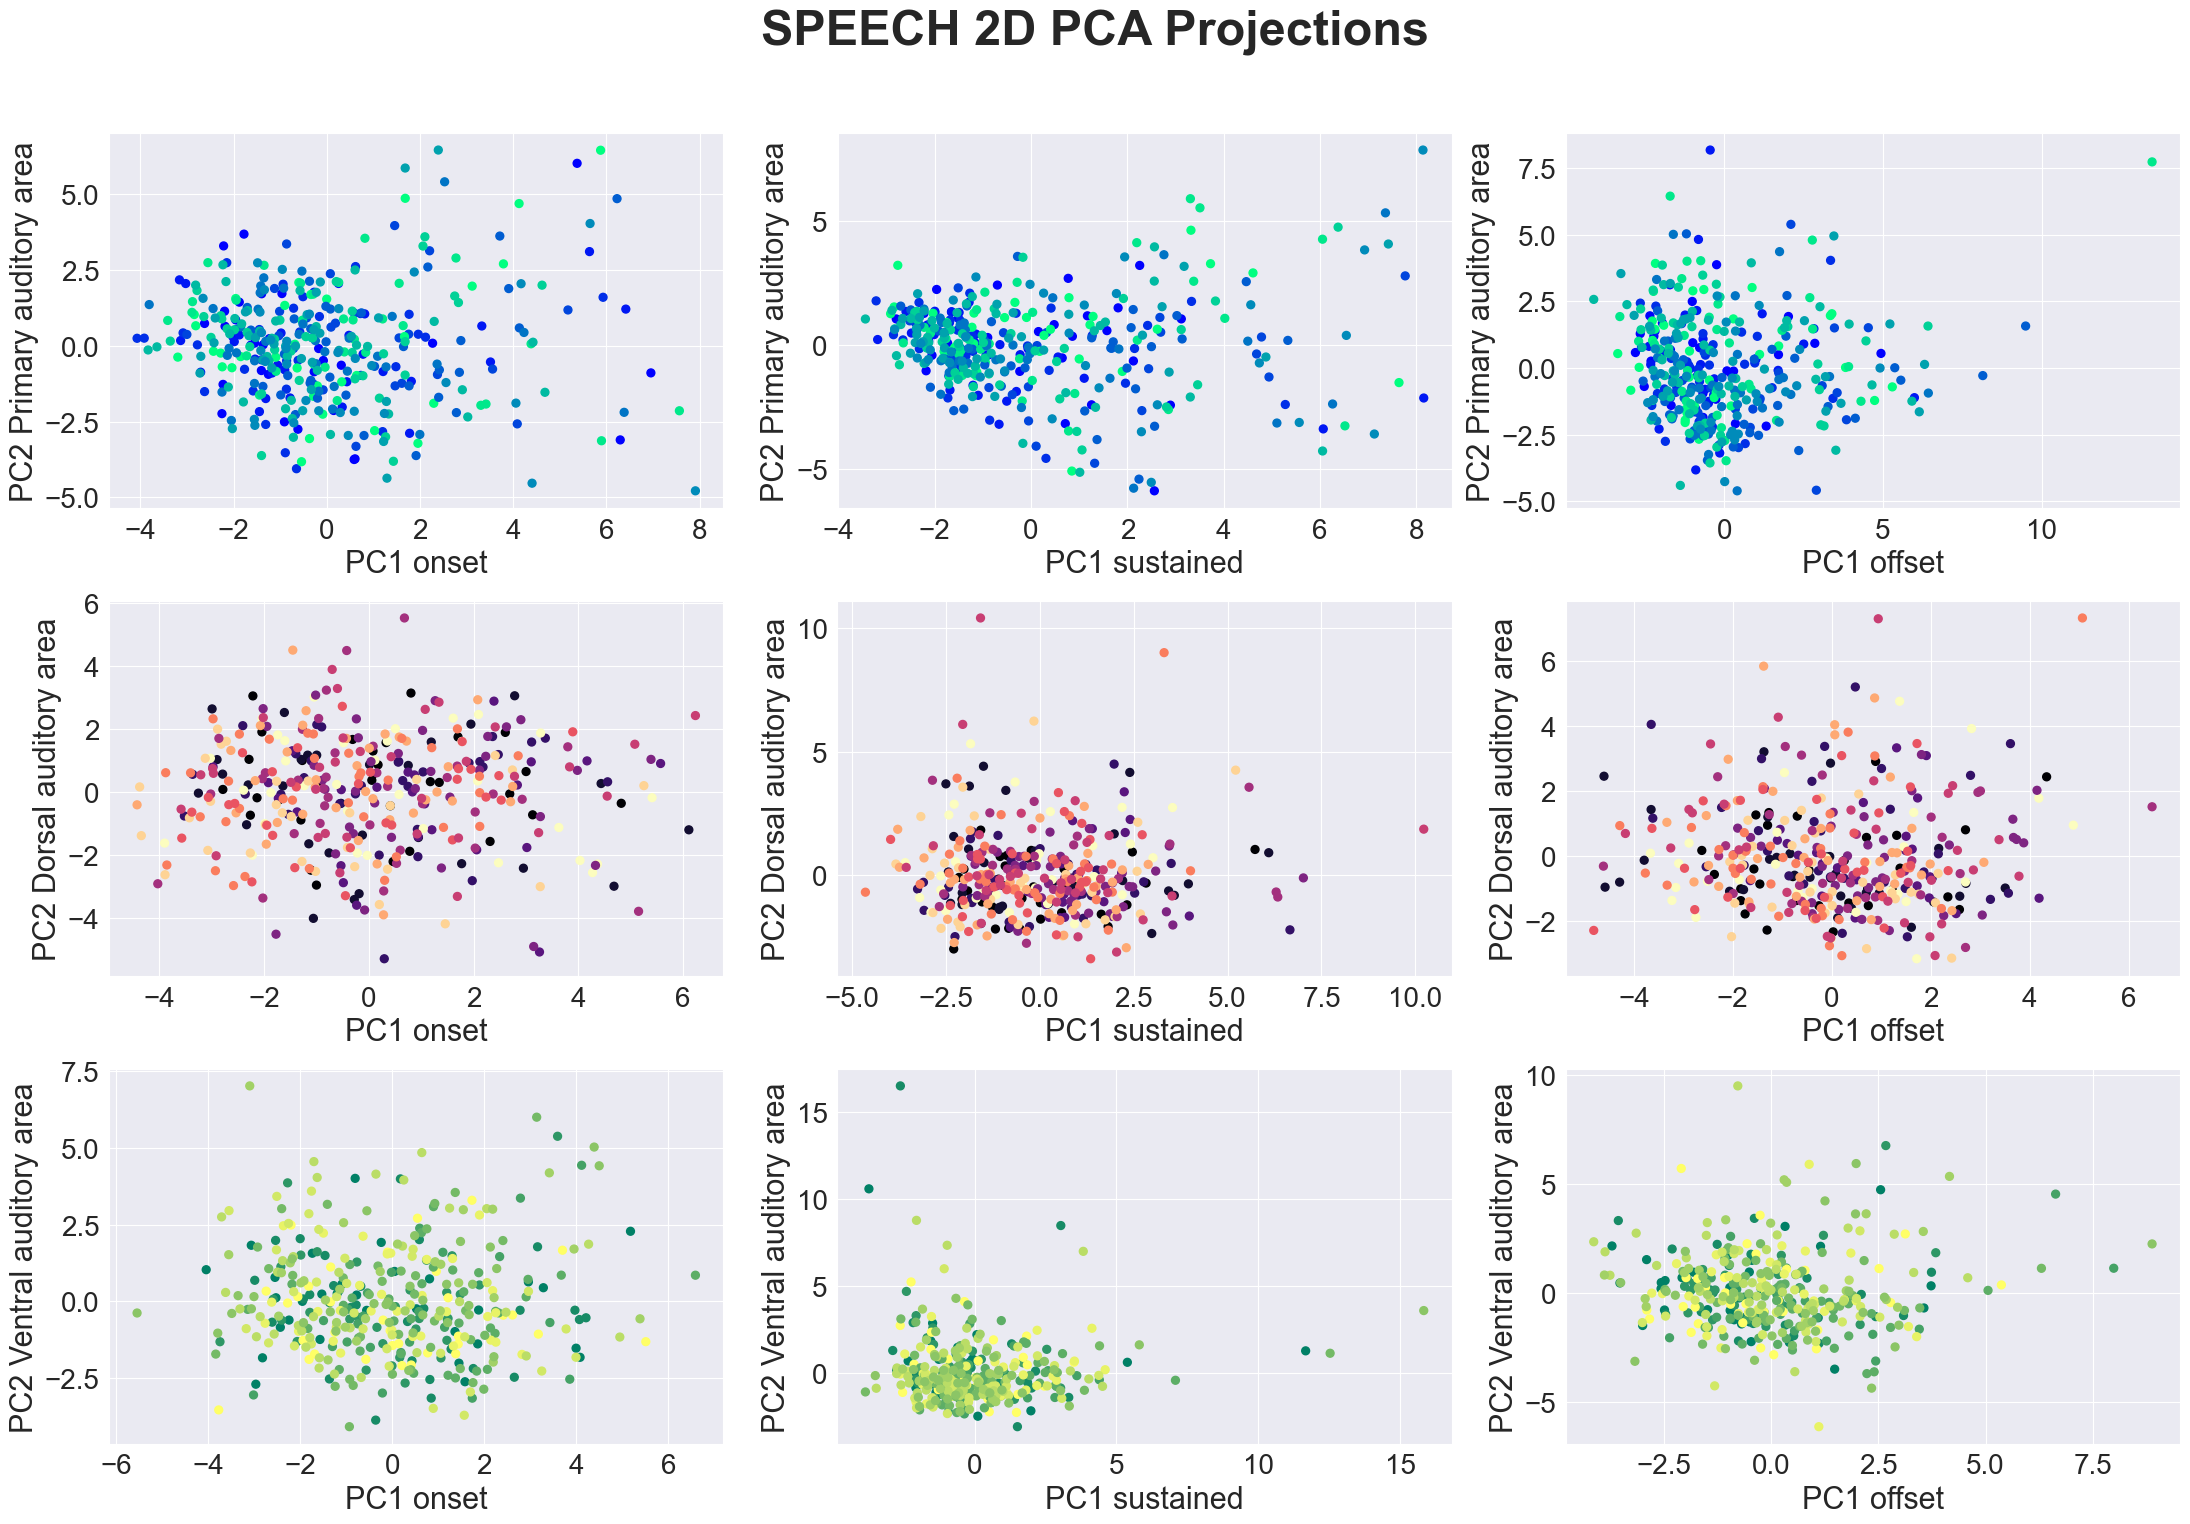

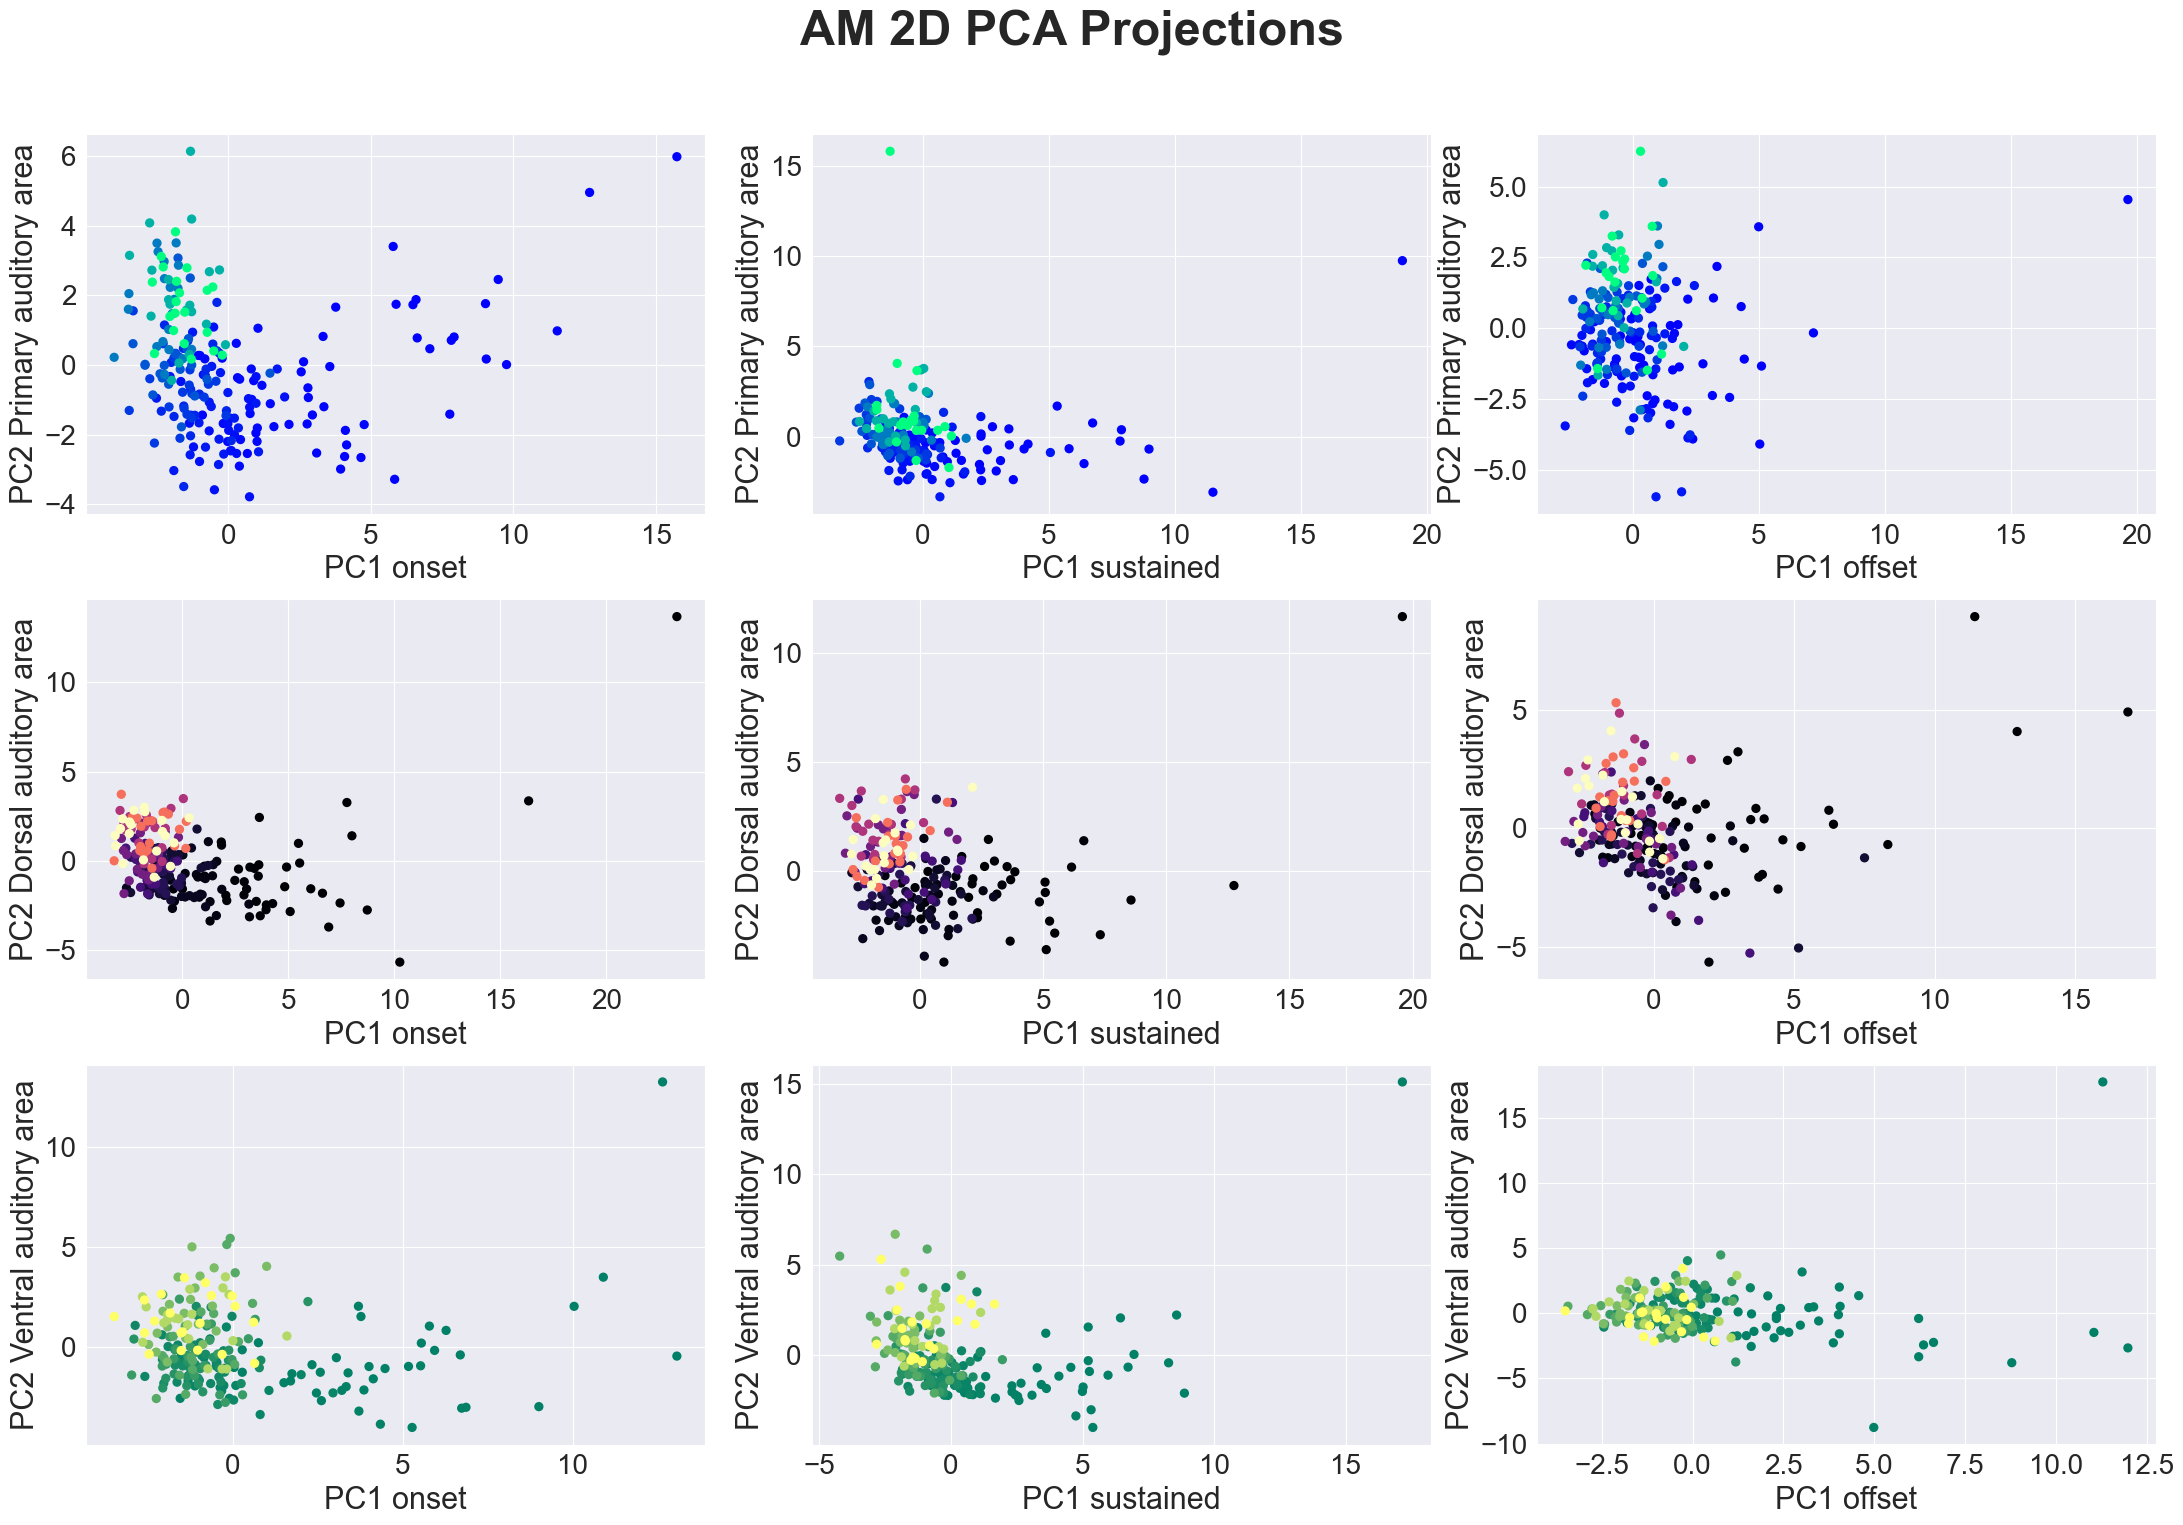

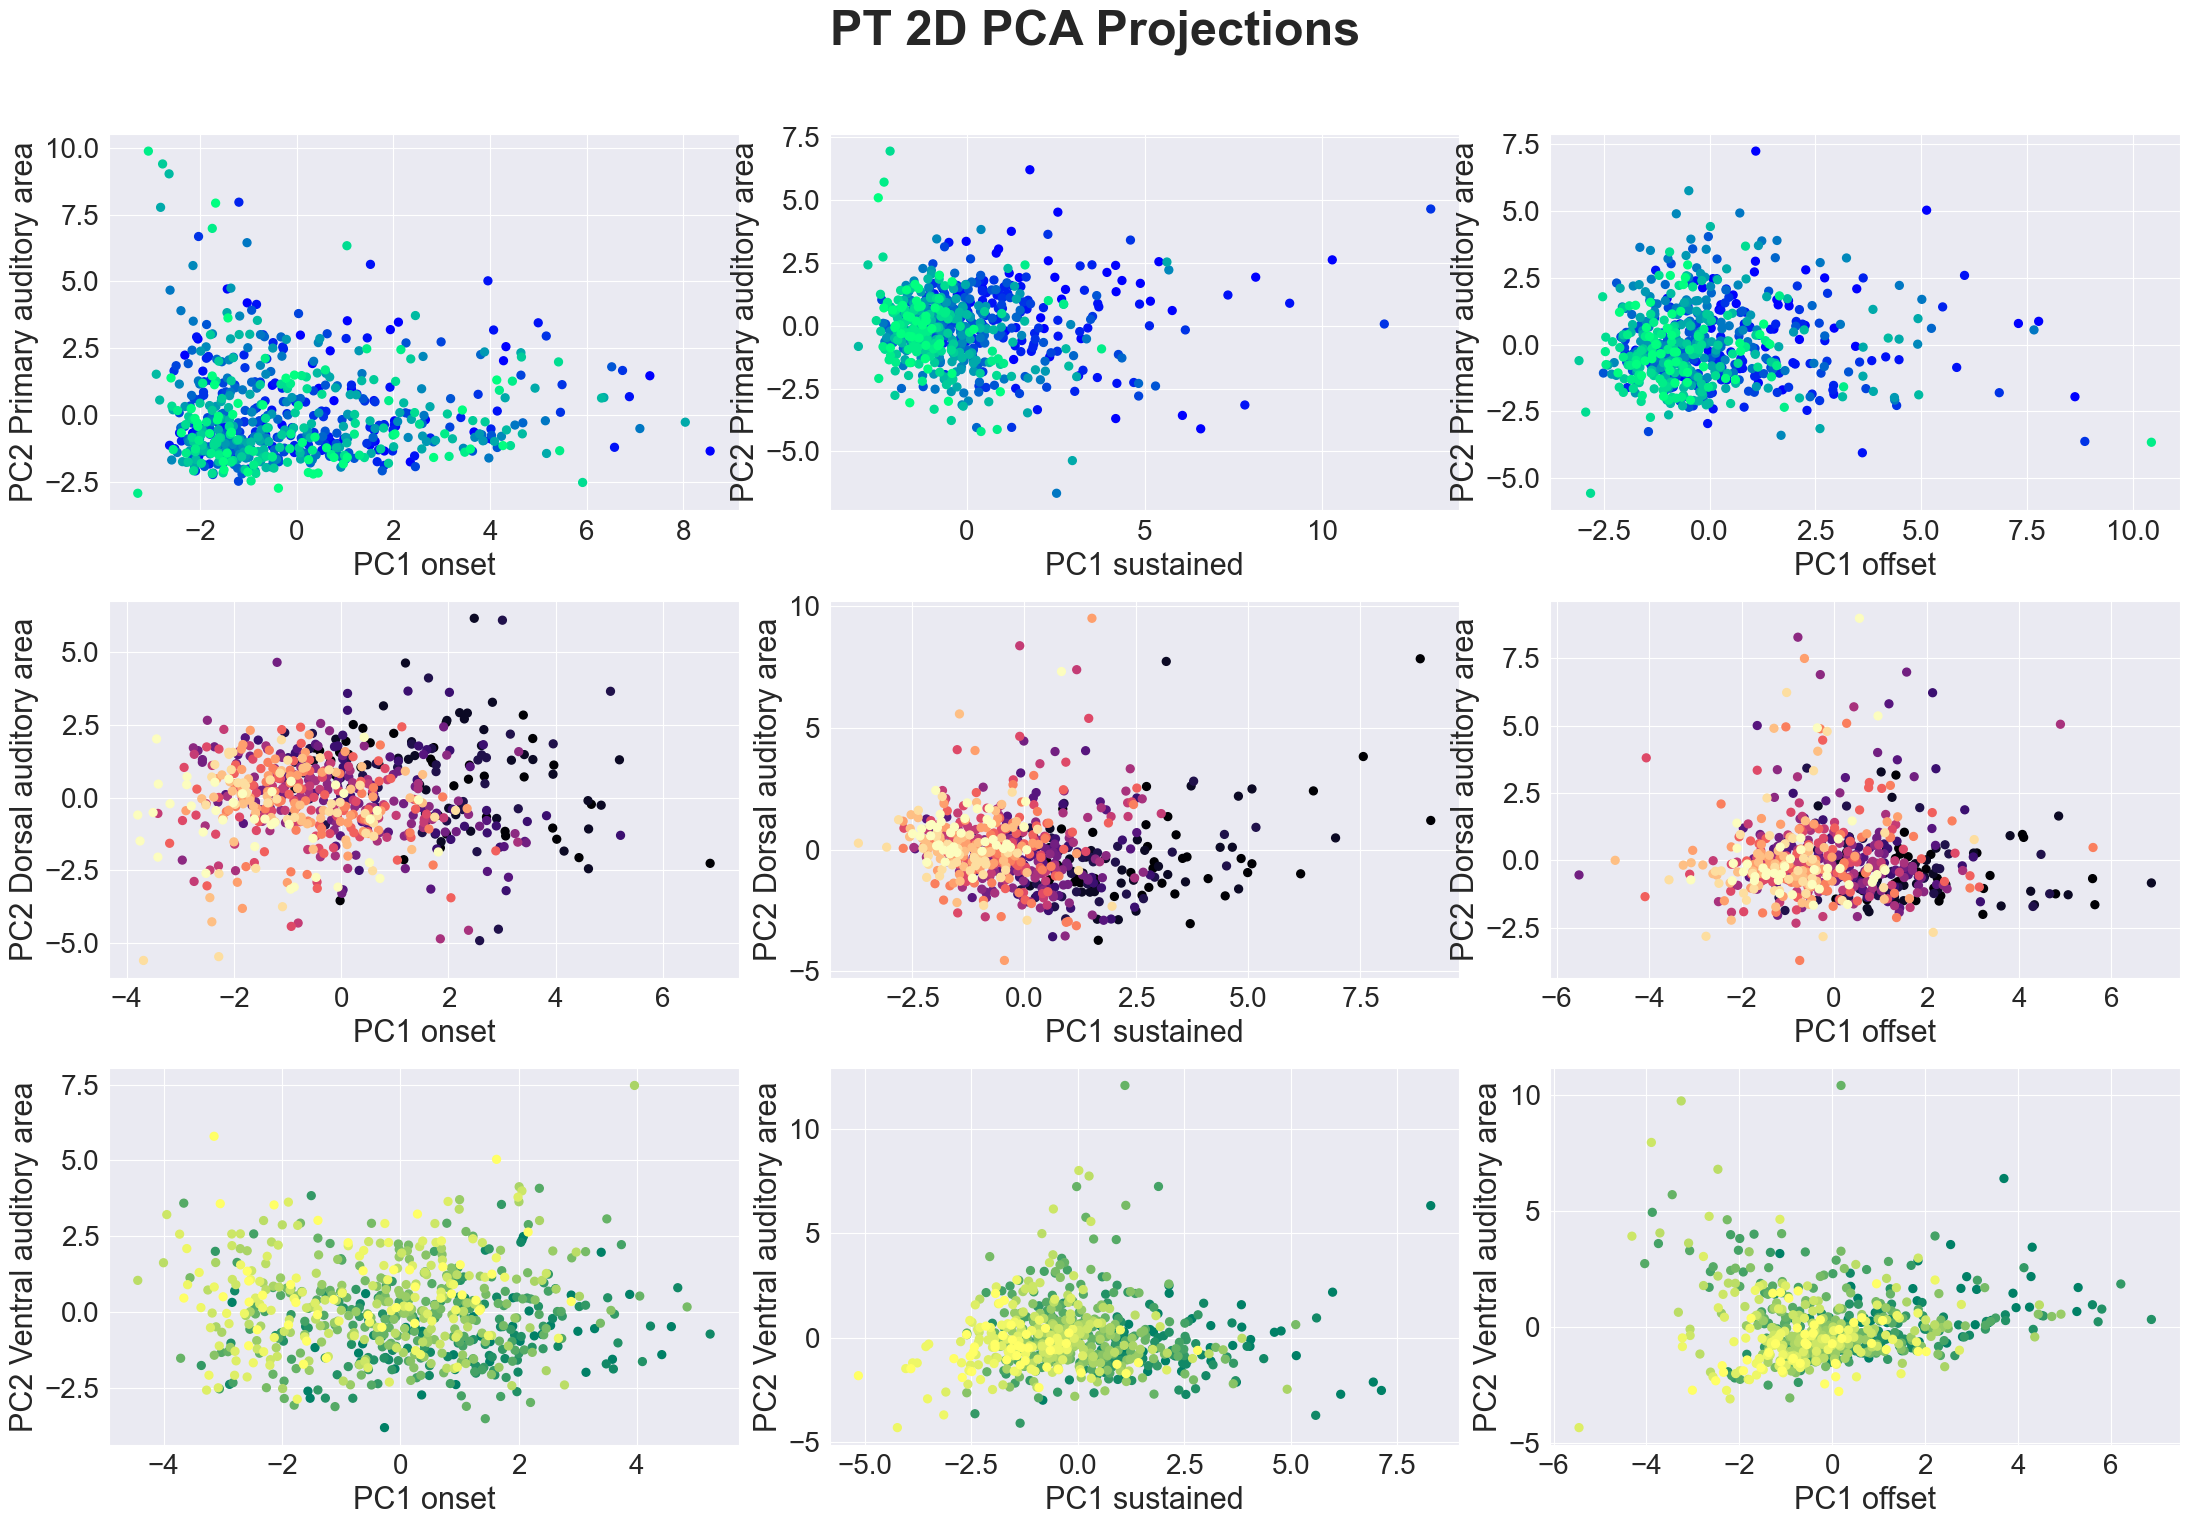

In [49]:
figsize = (22, 16)

for sound_type in ['speech', 'AM', 'PT']:
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    fig.suptitle(f'{sound_type.upper()} 2D PCA Projections', fontweight='bold', fontsize=35)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, brain_area in enumerate(params.targetSiteNames):
        for j, window_name in enumerate(spike_windows):
            ax = axes[i, j]
            key = (brain_area, sound_type, window_name)
            if key not in data_dict:
                ax.axis('off')
                continue

            data = data_dict[key]
            cmap = area_cmaps.get(brain_area, cm.viridis)
            X = data['X']
            if X.shape[1] < 2:
                ax.axis('off')
                continue

            selected = np.random.choice(X.shape[1], min(111, X.shape[1]), replace=False)
            X_sub = StandardScaler().fit_transform(X[:, selected])

            # Define color values
            if sound_type == 'speech':
                Y_labels = [tuple(row) for row in data['Y']]
                label_map = {(0,0):0, (0,33):1, (0,67):2, (0,100):3, (33,100):4, (67,100):5,
                             (100,100):6, (100,67):7, (100,33):8, (100,0):9, (67,0):10, (33,0):11}
                color_values = np.array([label_map.get(y, -1) for y in Y_labels])
            elif sound_type == 'PT':
                color_values = np.log10(data['Y'])
            else:
                color_values = data['Y']

            title = f"{brain_area.replace(' auditory area', '')} - {window_name.capitalize()}"
            funcs.plot_2d_pca(ax, {'X': X_sub, 'Y': data['Y']}, color_values, title, cmap=cmap)

            ax.tick_params(axis='both', labelsize=20)
            ax.set_xlabel(f"PC1 {window_name}", fontsize=22)
            ax.set_ylabel(f"PC2 {brain_area}", fontsize=22)

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
